-  0 denotes good risk (i.e. accept and issue load).
-  1 denotes bad risk (i.e. decline)

## Setting up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#conda update anaconda

In [3]:
#conda install -c anaconda graphviz

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_graphviz
from graphviz import Source

In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [6]:
pd.options.display.max_columns = None

In [7]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

## Importing data

In [8]:
df = pd.read_csv("new_file.csv")

In [9]:
df

,adopter,age,age_Missing,male,male_Missing,friend_cnt,subscriber_friend_cnt,avg_friend_age,avg_friend_age_Missing,avg_friend_male,avg_friend_male_Missing,friend_country_cnt,songsListened,playlists,posts,shouts,shouts_Missing,lovedTracks,tenure,good_country,good_country_Missing
0,0,24.386858,1,0.000000,0,20,1,30.285714,0,0.736842,0,14,8414,1,0,6.000000,0,348,59.0,1.000000,0
1,0,24.386858,1,0.623295,1,3,0,30.500000,0,0.333333,0,1,1943,0,0,3.000000,0,0,34.0,0.367819,1
2,0,22.000000,0,0.000000,0,8,0,22.571429,0,0.428571,0,1,9687,1,0,8.000000,0,194,59.0,1.000000,0
3,0,31.000000,0,0.000000,0,0,0,24.609796,1,0.631656,1,0,26863,0,0,2.000000,0,12,55.0,0.000000,0
4,0,24.386858,1,0.623295,1,1,0,24.609796,1,1.000000,0,1,187,0,0,7.000000,0,0,52.0,0.367819,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64462,1,24.000000,0,0.000000,0,28,3,23.666667,0,0.307692,0,8,37554,1,2,20.852649,1,556,46.0,0.000000,0
64463,1,27.000000,0,1.000000,0,8,0,27.666667,0,0.666667,0,2,12511,1,0,5.000000,0,1152,59.0,0.000000,0
64464,1,24.386858,1,0.623295,1,2,0,19.000000,0,1.000000,0,1,5917,11,0,1.000000,0,17,6.0,0.367819,1
64465,1,26.000000,0,0.000000,0,83,19,29.923077,0,0.820896,0,25,130029,3,11,287.000000,0,208,38.0,0.000000,0


## Train / Test split

In [10]:
y = df["adopter"]
X = df.drop("adopter", axis=1)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=886)

## Setting a classification threshold

In [12]:
mythreshold = 0.2

## Classification tree (max depth = 5; no CV)

In [13]:
treemod = DecisionTreeClassifier(max_depth=5, random_state=886)
treemod.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=886)

In [14]:
export_graphviz(
        treemod,
        out_file="high_notes.dot",
        feature_names=X_train.columns,
        impurity=False,
        rounded=True,
        filled=True
    )

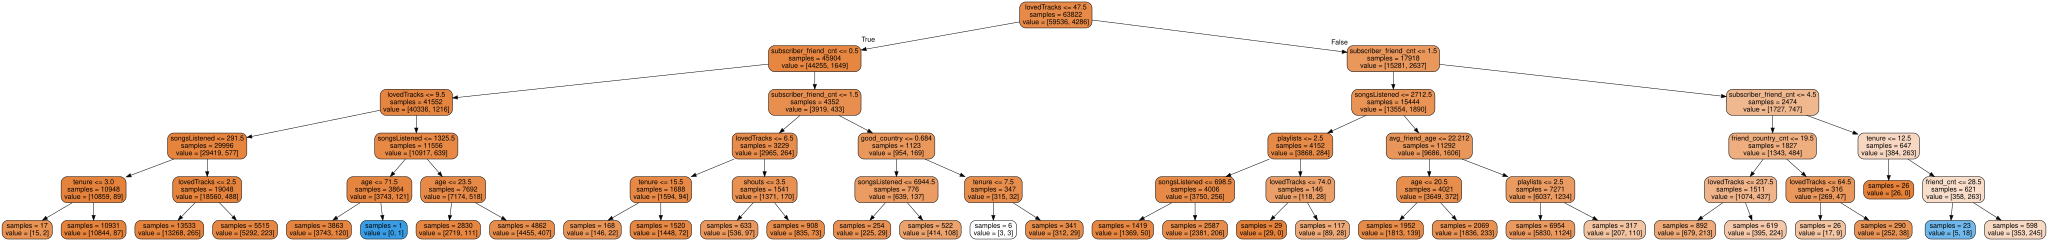

In [15]:
Source.from_file("high_notes.dot")

Reference:
https://scikit-learn.org/stable/modules/tree.html#mathematical-formulation

In [16]:
treemod_pred_prob = treemod.predict_proba(X_test)

In [17]:
treemod_pred_prob

array([[0.99204098, 0.00795902],
       [0.96893606, 0.03106394],
       [0.98041824, 0.01958176],
       ...,
       [0.88738521, 0.11261479],
       [0.98041824, 0.01958176],
       [0.95956482, 0.04043518]])

In [18]:
treemod_decisions = (treemod_pred_prob[:,1] >= mythreshold).astype(int)
treemod_decisions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,

In [19]:
treemod_cm = confusion_matrix(y_test, treemod_decisions)
treemod_cm

array([[585,  19],
       [ 32,   9]])

In [20]:
treemod_cm[1,0]

32

In [21]:
accuracy_score(y_test, treemod_decisions)

0.9209302325581395

In [22]:
sensitivity  = treemod_cm[1,1]/ (treemod_cm[1,1] + treemod_cm[1,0]) 
sensitivity

0.21951219512195122

In [23]:
specificity  = treemod_cm[0,0]/ (treemod_cm[0,0] + treemod_cm[0,1]) 
specificity

0.9685430463576159

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, treemod_pred_prob[:,1])

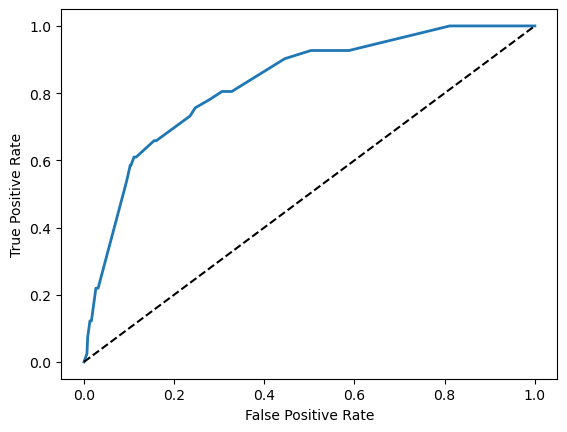

In [25]:
plot_roc_curve(fpr,tpr)
plt.show()

In [26]:
roc_auc_score(y_test, treemod_pred_prob[:,1])

0.8285818123081894

In [27]:
treemod_cm

array([[585,  19],
       [ 32,   9]])

In [28]:
treemod_cm[0,0]

585

In [29]:
treemod_cm[1,0]

32

In [30]:
sum(sum(treemod_cm))

645

In [31]:
treemod_profit = (1000 * treemod_cm[0,0] - 4000 * treemod_cm[1,0] ) / sum(sum(treemod_cm))
treemod_profit

708.5271317829457

## Classification tree with CV

In [32]:
treemod.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 886,
 'splitter': 'best'}

In [33]:
param_grid = [
  {'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10]} 
]

In [34]:
cv_grid = GridSearchCV(treemod, param_grid, scoring="roc_auc")

In [35]:
cv_grid.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(max_depth=5, random_state=886),
             param_grid=[{'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10]}],
             scoring='roc_auc')

In [36]:
pd.DataFrame(cv_grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.056850,0.012556,0.003529,0.000127,2,{'max_depth': 2},0.715311,0.729501,0.710904,0.714033,0.716239,0.717198,0.006410,9
1,0.073133,0.000415,0.003639,0.000078,3,{'max_depth': 3},0.749669,0.763086,0.741111,0.749207,0.743765,0.749368,0.007588,7
2,0.095485,0.000167,0.003739,0.000015,4,{'max_depth': 4},0.762866,0.774968,0.754471,0.765379,0.758856,0.763308,0.006904,5
3,0.117563,0.000451,0.003790,0.000056,5,{'max_depth': 5},0.766418,0.782149,0.762105,0.771379,0.763022,0.769015,0.007328,2
4,0.139488,0.000325,0.003877,0.000031,6,{'max_depth': 6},0.762451,0.782070,0.767721,0.775583,0.762502,0.770065,0.007684,1
5,0.162797,0.002850,0.004010,0.000051,7,{'max_depth': 7},0.763737,0.782302,0.764493,0.772535,0.757817,0.768177,0.008475,3
6,0.201510,0.036596,0.004180,0.000248,8,{'max_depth': 8},0.761356,0.776911,0.758833,0.769859,0.755627,0.764517,0.007791,4
7,0.205299,0.000282,0.004151,0.000083,9,{'max_depth': 9},0.749475,0.768063,0.758001,0.759839,0.739771,0.755030,0.009649,6
8,0.229220,0.002631,0.004424,0.000190,10,{'max_depth': 10},0.735159,0.744221,0.745007,0.748286,0.733623,0.741259,0.005792,8


## 6.3. Retraining and assessing the final model

In [37]:
treemod_final = DecisionTreeClassifier(max_depth=4, random_state=886)
treemod_final.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=886)

In [40]:
export_graphviz(
        treemod_final,
        out_file="high_note_final.dot",
        feature_names=X_train.columns,
        impurity=False,
        rounded=True,
        filled=True
    )

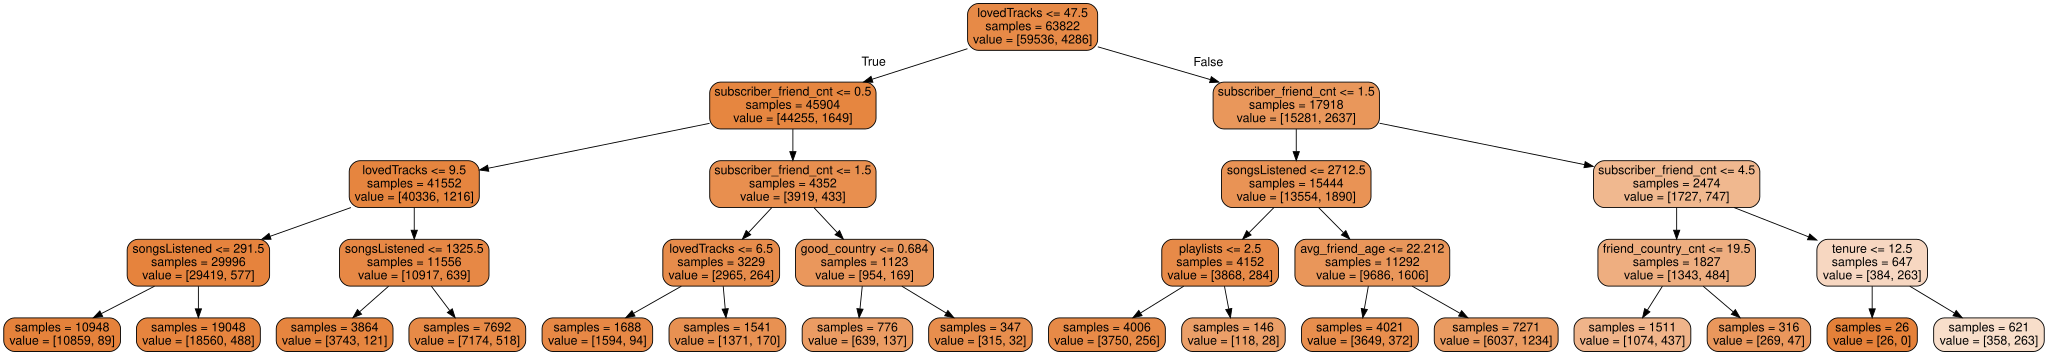

In [41]:
Source.from_file("high_note_final.dot")

Reference:
https://scikit-learn.org/stable/modules/tree.html#mathematical-formulation

In [42]:
treemod_final_pred_prob = treemod_final.predict_proba(X_test)

In [43]:
treemod_final_decisions = (treemod_final_pred_prob[:,1] >= mythreshold).astype(int)

In [44]:
treemod_final_cm = confusion_matrix(y_test, treemod_final_decisions)
treemod_final_cm

array([[593,  11],
       [ 34,   7]])

In [45]:
accuracy_score(y_test, treemod_final_decisions)

0.9302325581395349

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, treemod_final_pred_prob[:,1])

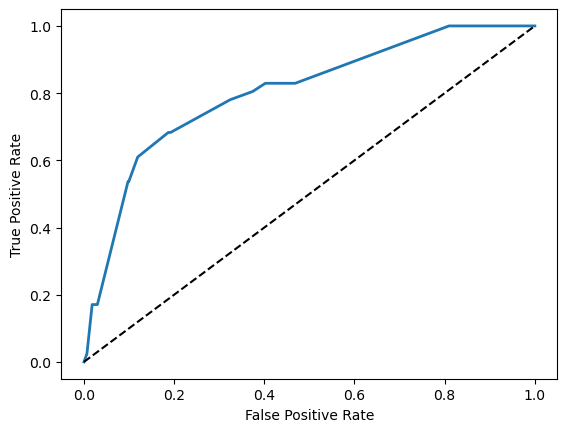

In [47]:
plot_roc_curve(fpr,tpr)
plt.show()

In [48]:
roc_auc_score(y_test, treemod_final_pred_prob[:,1])

0.8032829914391859

In [49]:
treemod_final_profit = (1000 * treemod_final_cm[0,0] - 4000 * treemod_final_cm[1,0] ) / sum(sum(treemod_final_cm))
treemod_final_profit

708.5271317829457

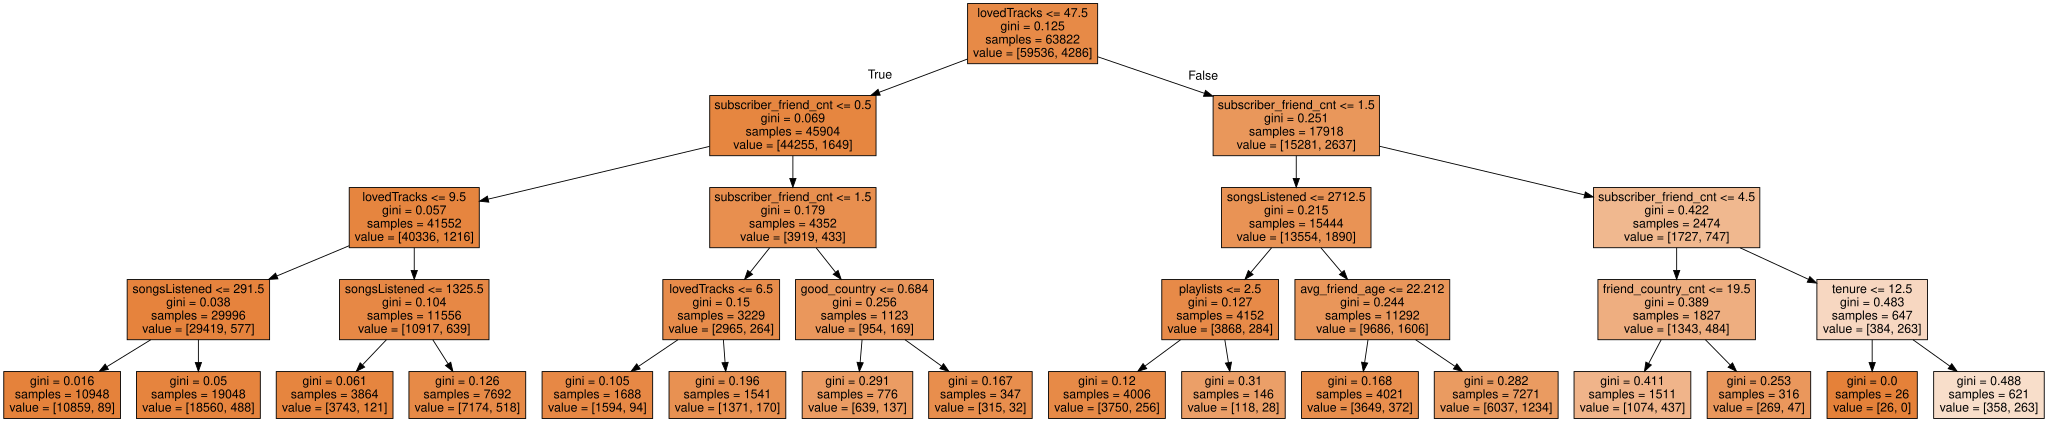

In [51]:
from sklearn import tree
import graphviz
# DOT data
dot_data = tree.export_graphviz(treemod_final, out_file=None, 
                                feature_names=X_train.columns,  
                                #class_names=(['1','0']),
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png") 
graph

In [52]:
graph.render("decision_tree_graphivz")

'decision_tree_graphivz.png'

In [53]:
importances = treemod_final.feature_importances_
sorted_indices = np.argsort(importances)[::-1]
 
feat_labels = X_train.columns[0:]
 
for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 50,
                            feat_labels[sorted_indices[f]],
                            importances[sorted_indices[f]]))

 1) lovedTracks                                        0.530669
 2) subscriber_friend_cnt                              0.312407
 3) songsListened                                      0.067613
 4) avg_friend_age                                     0.047404
 5) friend_country_cnt                                 0.015843
 6) tenure                                             0.013750
 7) playlists                                          0.007076
 8) good_country                                       0.005238
 9) good_country_Missing                               0.000000
10) age_Missing                                        0.000000
11) male                                               0.000000
12) male_Missing                                       0.000000
13) friend_cnt                                         0.000000
14) avg_friend_male_Missing                            0.000000
15) avg_friend_age_Missing                             0.000000
16) avg_friend_male                     

Text(0.5, 1.0, 'Feature Importance')

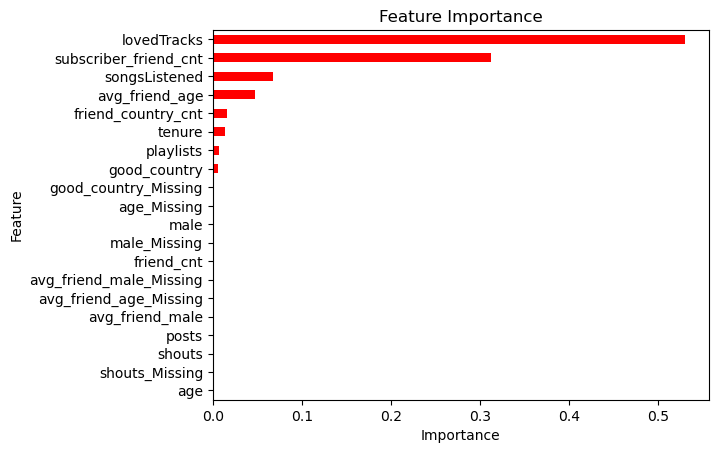

In [54]:
global_importances = pd.Series(treemod_final.feature_importances_, index=X_train.columns)
global_importances.sort_values(ascending=True, inplace=True)
global_importances.plot.barh(color='red')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

In [49]:
text_representation = tree.export_text(treemod_final)
print(text_representation)

|--- feature_16 <= 47.50
|   |--- feature_5 <= 0.50
|   |   |--- feature_16 <= 9.50
|   |   |   |--- feature_11 <= 291.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_11 >  291.50
|   |   |   |   |--- class: 0
|   |   |--- feature_16 >  9.50
|   |   |   |--- feature_11 <= 1325.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_11 >  1325.50
|   |   |   |   |--- class: 0
|   |--- feature_5 >  0.50
|   |   |--- feature_5 <= 1.50
|   |   |   |--- feature_16 <= 6.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_16 >  6.50
|   |   |   |   |--- class: 0
|   |   |--- feature_5 >  1.50
|   |   |   |--- feature_18 <= 0.68
|   |   |   |   |--- class: 0
|   |   |   |--- feature_18 >  0.68
|   |   |   |   |--- class: 0
|--- feature_16 >  47.50
|   |--- feature_5 <= 1.50
|   |   |--- feature_11 <= 2712.50
|   |   |   |--- feature_12 <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_12 >  2.50
|   |   |   |   |--- class: 0
|   |   |--- feature_11 >  2712.50
|  

## IRIS Dataset

In [64]:
from matplotlib import pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier 
from sklearn import tree

In [50]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [51]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [52]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [53]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [54]:
# Fit the classifier with default hyper-parameters
clf = DecisionTreeClassifier(random_state=1234)
model = clf.fit(X, y)

In [55]:
text_representation = tree.export_text(clf)
print(text_representation)

|--- feature_2 <= 2.45
|   |--- class: 0
|--- feature_2 >  2.45
|   |--- feature_3 <= 1.75
|   |   |--- feature_2 <= 4.95
|   |   |   |--- feature_3 <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  1.65
|   |   |   |   |--- class: 2
|   |   |--- feature_2 >  4.95
|   |   |   |--- feature_3 <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- feature_3 >  1.55
|   |   |   |   |--- feature_0 <= 6.95
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_0 >  6.95
|   |   |   |   |   |--- class: 2
|   |--- feature_3 >  1.75
|   |   |--- feature_2 <= 4.85
|   |   |   |--- feature_1 <= 3.10
|   |   |   |   |--- class: 2
|   |   |   |--- feature_1 >  3.10
|   |   |   |   |--- class: 1
|   |   |--- feature_2 >  4.85
|   |   |   |--- class: 2



In [56]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [57]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

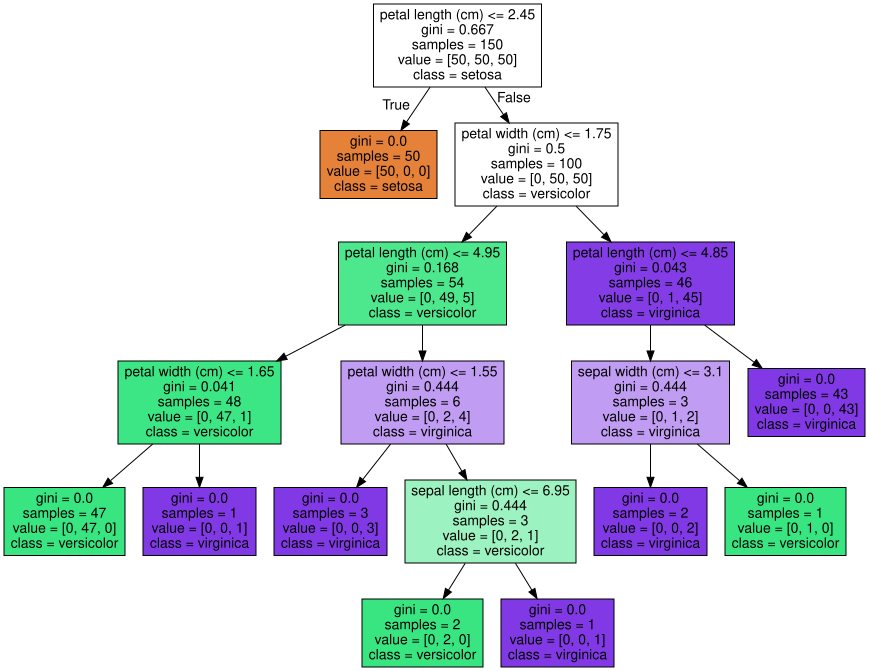

In [58]:
import graphviz
# DOT data
dot_data = tree.export_graphviz(clf, out_file=None, 
                                feature_names=iris.feature_names,  
                                class_names=iris.target_names,
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png") 
graph

In [59]:
graph.render("decision_tree_graphivz")

'decision_tree_graphivz.png'

In [60]:
!pip install 'graphviz==0.14.1' --force-reinstall

  Using cached graphviz-0.14.1-py2.py3-none-any.whl (18 kB)
  Attempting uninstall: graphviz
    Found existing installation: graphviz 0.14.1
    Uninstalling graphviz-0.14.1:
      Successfully uninstalled graphviz-0.14.1


In [61]:
!pip install dtreeviz 

In [62]:
from sklearn.datasets import *
from dtreeviz.trees import *
from IPython.display import Image, display_svg, SVG

In [63]:
from dtreeviz.trees import dtreeviz # remember to load the package

ImportError: cannot import name 'dtreeviz' from 'dtreeviz.trees' (/opt/anaconda3/lib/python3.9/site-packages/dtreeviz/trees.py)

In [ ]:
from dtreeviz.trees import ShadowDecTree

viz = dtreeviz(clf, X, y,
                target_name="target",
                feature_names=iris.feature_names,
                class_names=list(iris.target_names))

viz

In [ ]:
from dtreeviz.trees import dtreeviz # remember to load the package

viz = dtreeviz(clf, X, y,
                target_name="target",
                feature_names=iris.feature_names)
viz